# QF 627 Programming and Computational Finance 
## `Py`Day Week `4` | Problem-Sets for Exercise `3` | `RE`view

> "Hi Team! 👋

> Here we go again! The current script is prepared to help you to further exercise course content (But, again, do note that these are not assessment questions. They are for your exercise.)

> Some of the questions ask you to perform `reverse-engineering` 🧩. Instead of a question written in text format, you will be given the end results of some lines of code. Your task is to fill in the input cell with lines of code to create the output cell. Such a reverse-engineering exercise in computational programming will maximize your knowledge and skills in Computational Finance. 

> The questions below won’t be that difficult, as you have learned how to answer them from the lessons and the assigned readings. As you will notice from the questions, my intention is not just to give questions, but also to give additional learning pointers. I hope this helps 😊

> Enjoy!

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import datetime

import warnings
warnings.filterwarnings("ignore")

### Let's try to import historical stock data from the web and from your machine.

#### How to import from the Web

> You may use `yfinance` library.

In [2]:
import yfinance as yf

> Let's start & end dates--we are interested in year 2021 until August.

In [3]:
start = datetime.datetime(2024, 1, 1)
end = datetime.datetime(2024, 8, 31)

> Then, let's use [Yahoo! Finance](https://sg.finance.yahoo.com/) for extracting historical stock data.

In [ ]:
# apple =\
# (    yf
#      .download("AAPL",
#                start,
#                end)
# )

# google =\
# (    yf
#      .download("GOOGL", 
#                start,
#                end)
# )

> You may save the data to csv files.

In [17]:
apple =\
(
    pd
    .read_csv("http://www.talktoroh.com/s/apple_2024_stock.csv",
              index_col = 0,
              parse_dates = True)
)

In [18]:
apple

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-02,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
2024-01-03,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
2024-01-04,182.149994,183.089996,180.880005,181.910004,181.222321,71983600
2024-01-05,181.990005,182.759995,180.169998,181.179993,180.495087,62303300
2024-01-08,182.089996,185.600006,181.500000,185.559998,184.858521,59144500
...,...,...,...,...,...,...
2024-08-26,226.759995,227.279999,223.889999,227.179993,227.179993,30602200
2024-08-27,226.000000,228.850006,224.889999,228.029999,228.029999,35934600
2024-08-28,227.919998,229.860001,225.679993,226.490005,226.490005,38052200


In [9]:
google = pd.read_csv("http://www.talktoroh.com/s/google_2024_stock.csv")

#### Have a quick look at your data.

In [10]:
apple.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-02,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
1,2024-01-03,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
2,2024-01-04,182.149994,183.089996,180.880005,181.910004,181.222321,71983600
3,2024-01-05,181.990005,182.759995,180.169998,181.179993,180.495087,62303300
4,2024-01-08,182.089996,185.600006,181.500000,185.559998,184.858521,59144500


In [11]:
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-02,138.550003,139.449997,136.479996,138.169998,137.828705,23711200
1,2024-01-03,137.250000,139.630005,137.080002,138.919998,138.576859,24212100
2,2024-01-04,138.419998,139.160004,136.350006,136.389999,136.053101,27137700
3,2024-01-05,136.750000,137.160004,135.149994,135.729996,135.394745,22506000
4,2024-01-08,136.289993,139.009995,136.259995,138.839996,138.497055,21404000


In [12]:
apple.describe()

,Open,High,Low,Close,Adj Close,Volume
count,168.000000,168.000000,168.000000,168.000000,168.000000,1.680000e+02
mean,194.252380,196.172500,192.514821,194.389583,194.020255,6.168830e+07
std,20.554547,20.896348,20.132660,20.590587,20.712093,2.820863e+07
min,165.350006,166.399994,164.080002,165.000000,164.585999,3.029900e+07
25%,176.825001,178.592499,174.869999,178.139999,177.693039,4.596918e+07
50%,188.735001,190.285004,187.360001,188.740005,188.146538,5.353515e+07
75%,214.119995,216.962498,211.932499,214.252502,214.004791,6.862602e+07
max,236.479996,237.229996,233.089996,234.820007,234.548523,2.464214e+08


In [13]:
google.describe()

,Open,High,Low,Close,Adj Close,Volume
count,168.000000,168.000000,168.000000,168.000000,168.000000,1.680000e+02
mean,160.070476,161.745238,158.608928,160.225476,159.898376,2.762492e+07
std,15.661862,15.742355,15.547389,15.605793,15.629485,1.091537e+07
min,131.880005,133.240005,130.669998,131.399994,131.075424,1.024210e+07
25%,145.875000,146.632500,144.920006,145.977505,145.616940,2.103315e+07
50%,160.504997,163.440002,158.764999,160.834999,160.621857,2.448235e+07
75%,174.189995,175.357502,172.090000,173.610001,173.181171,3.117152e+07
max,190.309998,191.750000,189.029999,191.179993,190.926636,7.191000e+07


### We will `re-organize` and `re-shape` stock data

> Let's concatenate data in multiple DataFrame objects

> Let's obtain Apple adjusted close data for July and August 2024

In [16]:
apple

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-02,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
1,2024-01-03,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
2,2024-01-04,182.149994,183.089996,180.880005,181.910004,181.222321,71983600
3,2024-01-05,181.990005,182.759995,180.169998,181.179993,180.495087,62303300
4,2024-01-08,182.089996,185.600006,181.500000,185.559998,184.858521,59144500
...,...,...,...,...,...,...,...
163,2024-08-26,226.759995,227.279999,223.889999,227.179993,227.179993,30602200
164,2024-08-27,226.000000,228.850006,224.889999,228.029999,228.029999,35934600
165,2024-08-28,227.919998,229.860001,225.679993,226.490005,226.490005,38052200
166,2024-08-29,230.100006,232.919998,228.880005,229.789993,229.789993,51906300


In [21]:
apple.index.month

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
      dtype='int32', name='Date', length=168)

In [23]:
apple_july_2024 =\
(
    apple
    .loc[
        (apple.index.month == 7)
         &
        (apple.index.year == 2024)
        ]
    [["Adj Close"]]
)

apple_july_2024.head()

,Adj Close
Date,
2024-07-01,216.499405
2024-07-02,220.015335
2024-07-03,221.293854
2024-07-05,226.078308
2024-07-08,227.556610


In [24]:
apple_august_2024 =\
(
    apple
    .loc[
        (apple.index.month == 8)
         &
        (apple.index.year == 2024)
        ]
    [["Adj Close"]]
)

In [26]:
apple_august_2024.head()

,Adj Close
Date,
2024-08-01,218.107544
2024-08-02,219.605804
2024-08-05,209.028061
2024-08-06,206.990402
2024-08-07,209.577423


### Question 1-1. Please combine the first three rows of each of `apple_07` and `apple_08`

In [27]:
(
    pd
    .concat(
        [apple_july_2024.head(3), 
         apple_august_2024.head(3)
        ]
    )
)

,Adj Close
Date,
2024-07-01,216.499405
2024-07-02,220.015335
2024-07-03,221.293854
2024-08-01,218.107544
2024-08-02,219.605804
2024-08-05,209.028061


#### Question 1-2. How would you extract only the 2024 August GOOGL values?

In [29]:
google =\
(
    pd
    .read_csv("https://www.talktoroh.com/s/google_2024_stock.csv",
              index_col = 0,
              parse_dates = True)
)

In [30]:
google.head(3)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-02,138.550003,139.449997,136.479996,138.169998,137.828705,23711200
2024-01-03,137.250000,139.630005,137.080002,138.919998,138.576859,24212100
2024-01-04,138.419998,139.160004,136.350006,136.389999,136.053101,27137700


In [33]:
google.index.month

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
      dtype='int32', name='Date', length=168)

In [34]:
google_august_2024 =\
(
    google
    .loc[
         (google.index.month == 8)
         &
         (google.index.year == 2024)
        ]
    [["Adj Close"]]
)

In [35]:
google_august_2024

,Adj Close
Date,
2024-08-01,170.533707
2024-08-02,166.439148
2024-08-05,159.038971
2024-08-06,158.080231
2024-08-07,158.729370
2024-08-08,161.815277
2024-08-09,163.453110
2024-08-12,162.074921
2024-08-13,163.942459


#### Question 1-3. Please concatenate the AAPL and GOOGL 2024 August stock data--there will be duplicate index labels

In [36]:
concat_data =\
(
    pd
    .concat(
        [apple_august_2024,
         google_august_2024]
    )
)

(
    concat_data
    .loc[concat_data
         .index
         .isin(["2024-08-01", "2024-08-02", "2024-08-05"]
              )
        ]
)

,Adj Close
Date,
2024-08-01,218.107544
2024-08-02,219.605804
2024-08-05,209.028061
2024-08-01,170.533707
2024-08-02,166.439148
2024-08-05,159.038971


> Let's see the `two records for data of 2024-08-02`

In [37]:
concat_data.loc["2024-08-02"]

,Adj Close
Date,
2024-08-02,219.605804
2024-08-02,166.439148


#### Question 1-4. Please concatenate to show a specification of the stock tickers being part of the index. This will help disambiguate the duplicate dates using a hierarchal index.

In [41]:
concat_df =\
(
    pd
    .concat(
        [apple_august_2024,
         google_august_2024],
        keys = ["AAPL",
                "GOOGL"]
    )
)

concat_df\
    .loc[concat_df
         .index
         .isin(["2024-08-01", "2024-08-02", "2024-08-05"],
               level = 1)
]

Adj Close
      Date                  
AAPL  2024-08-01  218.107544
      2024-08-02  219.605804
      2024-08-05  209.028061
GOOGL 2024-08-01  170.533707
      2024-08-02  166.439148
      2024-08-05  159.038971

> Let's extract just GOOGL values using `.loc`

In [42]:
concat_df\
    .loc["GOOGL"]\
    .head(3)

,Adj Close
Date,
2024-08-01,170.533707
2024-08-02,166.439148
2024-08-05,159.038971


#### Question 1-5. Let's show concatenation using two DataFrame's that each have two columns.  `pandas` will align the data in columns by the column names (labels)

In [43]:
apple_price_volume =\
    apple[["Adj Close", "Volume"]]

google_price_volume =\
    google[["Adj Close", "Volume"]]

concat_DF =\
(
    pd
    .concat(
        [apple_price_volume,
         google_price_volume]
    )
)

concat_DF

,Adj Close,Volume
Date,,
2024-01-02,184.938217,82488700
2024-01-03,183.553467,58414500
2024-01-04,181.222321,71983600
2024-01-05,180.495087,62303300
2024-01-08,184.858521,59144500
...,...,...
2024-08-26,165.939804,14190400
2024-08-27,164.461761,11821900
2024-08-28,162.634201,16407400


> Let's see concatenation with DataFrame objects that do not have the same set of columns.

> This will show pandas filling in NaN values.

In [44]:
google_price =\
    google[["Adj Close"]]

In [45]:
concat_data =\
(
    pd
    .concat(
        [apple_price_volume,
         google_price]
    )
)

In [46]:
concat_data

,Adj Close,Volume
Date,,
2024-01-02,184.938217,82488700.0
2024-01-03,183.553467,58414500.0
2024-01-04,181.222321,71983600.0
2024-01-05,180.495087,62303300.0
2024-01-08,184.858521,59144500.0
...,...,...
2024-08-26,165.939804,NaN
2024-08-27,164.461761,NaN
2024-08-28,162.634201,NaN


### Question 2-1. Please perform an inner join on the DataFrame's since `google_a` does not have a Volume column, pandas will not include that column in the result.

In [47]:
concat_with_inner_join =\
(
    pd
    .concat(
        [apple_price_volume,
         google_price],
        join = "inner"
    )
)

concat_with_inner_join

,Adj Close
Date,
2024-01-02,184.938217
2024-01-03,183.553467
2024-01-04,181.222321
2024-01-05,180.495087
2024-01-08,184.858521
...,...
2024-08-26,165.939804
2024-08-27,164.461761
2024-08-28,162.634201


#### Question 2-2. Then, please concatenate along the rows, causing duplicate columns to be created in the result.

In [48]:
apple_price =\
    apple[["Adj Close"]]

In [52]:
concat_along_axis_1 =\
(
    pd
    .concat(
        [apple_price, google_price],
         axis = 1,
         keys = ["AAPL", "GOOGL"]
    )
)

In [57]:
concat_along_axis_1

,AAPL,GOOGL
,Adj Close,Adj Close
Date,,
2024-01-02,184.938217,137.828705
2024-01-03,183.553467,138.576859
2024-01-04,181.222321,136.053101
2024-01-05,180.495087,135.394745
2024-01-08,184.858521,138.497055
...,...,...
2024-08-26,227.179993,165.939804
2024-08-27,228.029999,164.461761


#### Question 2-3. Let's concat along rows using two DataFrame objects with different number of rows. 

#### This demonstrates how NaN values will be filled in those rows for `apple` which only has three rows as compared to 5 for `google`

In [55]:
# Apple

apple_5 =\
(
    apple
    [["Adj Close", "Volume"]]
    .head(5)
)

# Google

google_3 =\
(
    google
    [["Adj Close", "Volume"]]
    .head(3)
)

# concatenated_df

concat_along_axis_1_with_keys =\
(
    pd
    .concat(
        [apple_5, google_3],
         axis = 1,
         keys = ["AAPL", "GOOGL"]
    )
)

In [56]:
concat_along_axis_1_with_keys

AAPL                 GOOGL            
             Adj Close    Volume   Adj Close      Volume
Date                                                    
2024-01-02  184.938217  82488700  137.828705  23711200.0
2024-01-03  183.553467  58414500  138.576859  24212100.0
2024-01-04  181.222321  71983600  136.053101  27137700.0
2024-01-05  180.495087  62303300         NaN         NaN
2024-01-08  184.858521  59144500         NaN         NaN

#### Question 2-4. You know that `inner join` can also be used `along this axis`. 

#### Please include rows with index labels that do not exist in both DataFrame objects

In [58]:
concat_along_axis_1_with_keys_inner_join =\
(
    pd
    .concat(
        [apple_5, google_3],
         axis = 1,
         keys = ["AAPL", "GOOGL"],
         join = "inner"
    )
)

concat_along_axis_1_with_keys_inner_join

AAPL                 GOOGL          
             Adj Close    Volume   Adj Close    Volume
Date                                                  
2024-01-02  184.938217  82488700  137.828705  23711200
2024-01-03  183.553467  58414500  138.576859  24212100
2024-01-04  181.222321  71983600  136.053101  27137700

#### Question 2-5. Please ignore indexes and just concatenate the data and have the result have a default integer index

In [59]:
(
    pd
    .concat(
        [apple_5[["Adj Close"]].head(3), 
         google_3[["Adj Close"]]
        ],
        join = "inner",
        ignore_index = True
    )
)

,Adj Close
0,184.938217
1,183.553467
2,181.222321
3,137.828705
4,138.576859
5,136.053101


### `Now let's merging DataFrame objects`

In [60]:
apple_price.reset_index()

,Date,Adj Close
0,2024-01-02,184.938217
1,2024-01-03,183.553467
2,2024-01-04,181.222321
3,2024-01-05,180.495087
4,2024-01-08,184.858521
...,...,...
163,2024-08-26,227.179993
164,2024-08-27,228.029999
165,2024-08-28,226.490005
166,2024-08-29,229.789993


### Question 3-1. Please merge the two DataFrame objects, so lets peek at the data to remind ourselves of what they contain.

###  `pandas` finds the columns in common, in this case Date, and merges on that column and adds a column for all the other columns in both DataFrames.

In [61]:
%who

apple	 apple_5	 apple_august_2024	 apple_july_2024	 apple_price	 apple_price_volume	 concat_DF	 concat_along_axis_1	 concat_along_axis_1_with_keys	 
concat_along_axis_1_with_keys_inner_join	 concat_data	 concat_df	 concat_with_inner_join	 datetime	 end	 google	 google_3	 google_august_2024	 
google_price	 google_price_volume	 np	 pd	 plt	 start	 warnings	 yf	 


In [62]:
apple_price_5 =\
    apple_price\
    .reset_index()\
    .head(5)

apple_volume_5 =\
    apple\
    [["Volume"]]\
    .reset_index()\
    .head(5)

In [63]:
merged_df =\
(
    apple_price_5
    .merge(apple_volume_5,
           on = "Date")
)

merged_df

,Date,Adj Close,Volume
0,2024-01-02,184.938217,82488700
1,2024-01-03,183.553467,58414500
2,2024-01-04,181.222321,71983600
3,2024-01-05,180.495087,62303300
4,2024-01-08,184.858521,59144500


#### Question 3-2. Please use the merge function to create the below.

In [64]:
(
    apple_price_5
    .merge(apple_volume_5.iloc[2:4],
           on = "Date")
)

,Date,Adj Close,Volume
0,2024-01-04,181.222321,71983600
1,2024-01-05,180.495087,62303300


#### Question 3-3. How would you create the below then?

In [65]:
merged_with_on_how =\
(
    apple_price_5
    .merge(apple_volume_5.iloc[2:4],
           on = "Date",
           how = "left")
)

merged_with_on_how

,Date,Adj Close,Volume
0,2024-01-02,184.938217,NaN
1,2024-01-03,183.553467,NaN
2,2024-01-04,181.222321,71983600.0
3,2024-01-05,180.495087,62303300.0
4,2024-01-08,184.858521,NaN


### Let's do some `pivoting`

In [67]:
apple["Symbol"] = "AAPL"
google["Symbol"] = "GOOGL"

### Question 4-1. Please insert `Symbol` column before combining

#### Question 4-2. Please concatenate the `Apple` and `Google` data index will consist of the Date column, which we will sort.

In [69]:
concate_2024 =\
(
    pd
    .concat(
            [apple,
             google]
            )
    .sort_index()
)

In [70]:
concate_2024.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Symbol'], dtype='object')

In [71]:
cols = ['Symbol', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
concate_2024 = concate_2024[cols]

concate_2024

,Symbol,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2024-01-02,AAPL,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
2024-01-02,GOOGL,138.550003,139.449997,136.479996,138.169998,137.828705,23711200
2024-01-03,GOOGL,137.250000,139.630005,137.080002,138.919998,138.576859,24212100
2024-01-03,AAPL,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
2024-01-04,AAPL,182.149994,183.089996,180.880005,181.910004,181.222321,71983600
...,...,...,...,...,...,...,...
2024-08-28,AAPL,227.919998,229.860001,225.679993,226.490005,226.490005,38052200
2024-08-29,GOOGL,164.309998,165.970001,160.250000,161.779999,161.565613,19699800
2024-08-29,AAPL,230.100006,232.919998,228.880005,229.789993,229.789993,51906300


#### Question 4-3. Please pushes the index into a column and resets to a default integer index.

In [72]:
concate_2024 = concate_2024.reset_index()

concate_2024.head()

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2024-01-02,AAPL,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
1,2024-01-02,GOOGL,138.550003,139.449997,136.479996,138.169998,137.828705,23711200
2,2024-01-03,GOOGL,137.250000,139.630005,137.080002,138.919998,138.576859,24212100
3,2024-01-03,AAPL,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
4,2024-01-04,AAPL,182.149994,183.089996,180.880005,181.910004,181.222321,71983600


#### Question 4-4. Please pivot Date into the Index, make the columns match the unique values in the Symbol column, and the values will be the AdjClose values

In [73]:
pivot_df =\
(
    concate_2024
    .pivot(index = "Date",
           columns = "Symbol",
           values = "Adj Close")
)

pivot_df

Symbol,AAPL,GOOGL
Date,,
2024-01-02,184.938217,137.828705
2024-01-03,183.553467,138.576859
2024-01-04,181.222321,136.053101
2024-01-05,180.495087,135.394745
2024-01-08,184.858521,138.497055
...,...,...
2024-08-26,227.179993,165.939804
2024-08-27,228.029999,164.461761
2024-08-28,226.490005,162.634201


### Let's execute `stacking` and `unstacking`

### Question 5-1. Please stack the first level of columns into the index.

### Let's move AAPL and GOOGL into the index leaving a single colum which is the AdjClose values

In [74]:
pivot_df.head()

Symbol,AAPL,GOOGL
Date,,
2024-01-02,184.938217,137.828705
2024-01-03,183.553467,138.576859
2024-01-04,181.222321,136.053101
2024-01-05,180.495087,135.394745
2024-01-08,184.858521,138.497055


In [75]:
stacked_df =\
(
    pivot_df
    .stack()
)

In [76]:
stacked_df

Date        Symbol
2024-01-02  AAPL      184.938217
            GOOGL     137.828705
2024-01-03  AAPL      183.553467
            GOOGL     138.576859
2024-01-04  AAPL      181.222321
                         ...    
2024-08-28  GOOGL     162.634201
2024-08-29  AAPL      229.789993
            GOOGL     161.565613
2024-08-30  AAPL      229.000000
            GOOGL     163.163498
Length: 336, dtype: float64

In [77]:
type(stacked_df)

pandas.core.series.Series

> Using `.loc` we can retrieve close values by specifying both the date and ticker

In [78]:
stacked_df\
    .loc[("2024-01-04", "AAPL")
         ]

181.22232055664065

#### Question 5-2. Please lookup on just the date, which will give us two values one each for AAPL and GOOGL.  

In [79]:
stacked_df\
    .loc[("2024-01-04", )
         ]

Symbol
AAPL     181.222321
GOOGL    136.053101
dtype: float64

> Let's have a look at all values for the GOOGL symbol

In [80]:
stacked_df\
    .loc[ : , "GOOGL"]

Date
2024-01-02    137.828705
2024-01-03    138.576859
2024-01-04    136.053101
2024-01-05    135.394745
2024-01-08    138.497055
                 ...    
2024-08-26    165.939804
2024-08-27    164.461761
2024-08-28    162.634201
2024-08-29    161.565613
2024-08-30    163.163498
Length: 168, dtype: float64

#### Question 5-3. Please pivot the last level of the index back into a column

In [81]:
unstacked_df =\
(
    stacked_df
    .unstack()
)

unstacked_df.head(3)

Symbol,AAPL,GOOGL
Date,,
2024-01-02,184.938217,137.828705
2024-01-03,183.553467,138.576859
2024-01-04,181.222321,136.053101


### Now, let's do some `melting`

### Question 6-1. Please use `melt` to make id_vars of Date and Symbol, making the column names the variable and the for each the value

In [84]:
%who

apple	 apple_5	 apple_august_2024	 apple_july_2024	 apple_price	 apple_price_5	 apple_price_volume	 apple_volume_5	 cols	 
concat_DF	 concat_along_axis_1	 concat_along_axis_1_with_keys	 concat_along_axis_1_with_keys_inner_join	 concat_data	 concat_df	 concat_with_inner_join	 concate_2024	 datetime	 
end	 google	 google_3	 google_august_2024	 google_price	 google_price_volume	 merged_df	 merged_with_on_how	 np	 
pd	 pivot_df	 plt	 stacked_df	 start	 unstacked_df	 warnings	 yf	 


In [85]:
concate_2024 # WIDE format

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2024-01-02,AAPL,187.149994,188.440002,183.889999,185.639999,184.938217,82488700
1,2024-01-02,GOOGL,138.550003,139.449997,136.479996,138.169998,137.828705,23711200
2,2024-01-03,GOOGL,137.250000,139.630005,137.080002,138.919998,138.576859,24212100
3,2024-01-03,AAPL,184.220001,185.880005,183.429993,184.250000,183.553467,58414500
4,2024-01-04,AAPL,182.149994,183.089996,180.880005,181.910004,181.222321,71983600
...,...,...,...,...,...,...,...,...
331,2024-08-28,AAPL,227.919998,229.860001,225.679993,226.490005,226.490005,38052200
332,2024-08-29,GOOGL,164.309998,165.970001,160.250000,161.779999,161.565613,19699800
333,2024-08-29,AAPL,230.100006,232.919998,228.880005,229.789993,229.789993,51906300
334,2024-08-30,AAPL,230.190002,230.399994,227.479996,229.000000,229.000000,52990800


In [87]:
melted_df =\
(
    pd
    .melt(concate_2024,
          id_vars = ["Date", "Symbol"]
         ) # reshape your tabular data from WIDE format to LONG format
)

melted_df.head()

,Date,Symbol,variable,value
0,2024-01-02,AAPL,Open,187.149994
1,2024-01-02,GOOGL,Open,138.550003
2,2024-01-03,GOOGL,Open,137.250000
3,2024-01-03,AAPL,Open,184.220001
4,2024-01-04,AAPL,Open,182.149994


#### Question 6-2. Please extract the values for the data for Google on 2024-08-23

In [88]:
melted_df\
    [(melted_df.Date == "2024-08-23") & (melted_df.Symbol == "GOOGL")]

,Date,Symbol,variable,value
325,2024-08-23,GOOGL,Open,1.647200e+02
661,2024-08-23,GOOGL,High,1.661800e+02
997,2024-08-23,GOOGL,Low,1.638300e+02
1333,2024-08-23,GOOGL,Close,1.656200e+02
1669,2024-08-23,GOOGL,Adj Close,1.654005e+02
2005,2024-08-23,GOOGL,Volume,1.395570e+07


### Let's do some grouping and aggregation

##### To do so, we will do some splitting first.

> Let's construct a DataFrame to demonstrate splitting

### Question 7-1. Please extract from combined the Symbol and AdjClose, and reset the index

In [89]:
concat_price =\
(
    concate_2024
    [["Date",	"Symbol",	"Adj Close"]]
)

concat_price

,Date,Symbol,Adj Close
0,2024-01-02,AAPL,184.938217
1,2024-01-02,GOOGL,137.828705
2,2024-01-03,GOOGL,138.576859
3,2024-01-03,AAPL,183.553467
4,2024-01-04,AAPL,181.222321
...,...,...,...
331,2024-08-28,AAPL,226.490005
332,2024-08-29,GOOGL,161.565613
333,2024-08-29,AAPL,229.789993
334,2024-08-30,AAPL,229.000000


#### Question 7-2. Please add two columns, year and month, using the year and month portions of the data as integers

In [90]:
concat_price["Year"] =\
(
    concat_price
    .Date
    .dt
    .year
)

order_of_columns = ["Date",	"Year",	"Symbol", "Adj Close"]

concat_price = concat_price[order_of_columns]

concat_price

,Date,Year,Symbol,Adj Close
0,2024-01-02,2024,AAPL,184.938217
1,2024-01-02,2024,GOOGL,137.828705
2,2024-01-03,2024,GOOGL,138.576859
3,2024-01-03,2024,AAPL,183.553467
4,2024-01-04,2024,AAPL,181.222321
...,...,...,...,...
331,2024-08-28,2024,AAPL,226.490005
332,2024-08-29,2024,GOOGL,161.565613
333,2024-08-29,2024,AAPL,229.789993
334,2024-08-30,2024,AAPL,229.000000


In [91]:
concat_price["Month"] =\
(
    concat_price
    .Date
    .dt
    .month
)

order_of_columns = ["Date",	"Year",	"Month", "Symbol", "Adj Close"]

concat_price = concat_price[order_of_columns]

concat_price

# The above is okay :)
# Recommended way ==> try to use .insert()

,Date,Year,Month,Symbol,Adj Close
0,2024-01-02,2024,1,AAPL,184.938217
1,2024-01-02,2024,1,GOOGL,137.828705
2,2024-01-03,2024,1,GOOGL,138.576859
3,2024-01-03,2024,1,AAPL,183.553467
4,2024-01-04,2024,1,AAPL,181.222321
...,...,...,...,...,...
331,2024-08-28,2024,8,AAPL,226.490005
332,2024-08-29,2024,8,GOOGL,161.565613
333,2024-08-29,2024,8,AAPL,229.789993
334,2024-08-30,2024,8,AAPL,229.000000


> Let's group by the Symbol column

In [92]:
grouped_df =\
(
    concat_price
    .groupby(by = "Symbol")
)

grouped_df

> Here, please save the result!

In [54]:
# Yay!

> The groupby object has a property groups, which shows how all rows will in mapped into the groups.

> The type of this object is a python dict

In [93]:
type(grouped_df.groups)

pandas.io.formats.printing.PrettyDict

> Let's show the mappings of rows to groups

In [94]:
grouped_df.groups

{'AAPL': [0, 3, 4, 6, 8, 11, 13, 15, 17, 19, 21, 23, 24, 26, 29, 31, 32, 34, 36, 38, 41, 43, 44, 47, 49, 50, 52, 55, 56, 59, 61, 63, 65, 66, 69, 70, 73, 75, 76, 79, 80, 83, 85, 86, 89, 90, 92, 95, 97, 98, 101, 102, 104, 106, 108, 111, 113, 115, 117, 118, 120, 123, 125, 127, 129, 130, 133, 134, 136, 138, 140, 143, 145, 147, 149, 151, 152, 155, 156, 159, 161, 162, 165, 166, 169, 171, 172, 175, 177, 179, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, ...], 'GOOGL': [1, 2, 5, 7, 9, 10, 12, 14, 16, 18, 20, 22, 25, 27, 28, 30, 33, 35, 37, 39, 40, 42, 45, 46, 48, 51, 53, 54, 57, 58, 60, 62, 64, 67, 68, 71, 72, 74, 77, 78, 81, 82, 84, 87, 88, 91, 93, 94, 96, 99, 100, 103, 105, 107, 109, 110, 112, 114, 116, 119, 121, 122, 124, 126, 128, 131, 132, 135, 137, 139, 141, 142, 144, 146, 148, 150, 153, 154, 157, 158, 160, 163, 164, 167, 168, 170, 173, 174, 176, 178, 181, 183, 185, 187, 189, 191, 193, 195, 197, 199, ...]}

> Yes, this reports the number of groups that resulted from the grouping

In [96]:
grouped_df.ngroups, len(grouped_df)

(2, 2)

In [98]:
(
    concat_price
    .groupby("Symbol")
    [["Year", "Month"]]
    .mean()
    .shape
)

(2, 2)

### Question 8-1. Please create a function that prints the contents of a group. You might want to look at the outputs below for hints.

In [99]:
dict(grouped_df.groups)

{'AAPL': Index([  0,   3,   4,   6,   8,  11,  13,  15,  17,  19,
        ...
        317, 319, 321, 323, 324, 327, 329, 331, 333, 334],
       dtype='int64', length=168),
 'GOOGL': Index([  1,   2,   5,   7,   9,  10,  12,  14,  16,  18,
        ...
        316, 318, 320, 322, 325, 326, 328, 330, 332, 335],
       dtype='int64', length=168)}

In [97]:
concat_price

,Date,Year,Month,Symbol,Adj Close
0,2024-01-02,2024,1,AAPL,184.938217
1,2024-01-02,2024,1,GOOGL,137.828705
2,2024-01-03,2024,1,GOOGL,138.576859
3,2024-01-03,2024,1,AAPL,183.553467
4,2024-01-04,2024,1,AAPL,181.222321
...,...,...,...,...,...
331,2024-08-28,2024,8,AAPL,226.490005
332,2024-08-29,2024,8,GOOGL,161.565613
333,2024-08-29,2024,8,AAPL,229.789993
334,2024-08-30,2024,8,AAPL,229.000000


###  When you execute your function you should see the following results.

In [103]:
prep_df = dict(grouped_df.groups)

In [101]:
# Verbose function ==> do NOT write code this way :)

def display_all_the_values(n):
    apple_df = pd.DataFrame([])
    google_df = pd.DataFrame([])

    for i in range(concat_price.shape[0]
                  ):
        if concat_price.index[i] in prep_df["AAPL"]:
            apple_df = pd.concat([apple_df, concat_price.loc[i]
                                 ],
                                 axis = 1
                                )
        elif concat_price.index[i] in prep_df["GOOGL"]:
            google_df = pd.concat([google_df, concat_price.loc[i]
                                  ],
                                  axis = 1
                                 )

    apple_df = apple_df.transpose()
    google_df = google_df.transpose()

    print("AAPL")
    print(apple_df.head(n)
         )

    print("GOOGL")
    print(google_df.head(n)
         )

# 28 lines of code

In [104]:
display_all_the_values(5)

AAPL
        Date  Year Month Symbol   Adj Close
0 2024-01-02  2024     1   AAPL  184.938217
3 2024-01-03  2024     1   AAPL  183.553467
4 2024-01-04  2024     1   AAPL  181.222321
6 2024-01-05  2024     1   AAPL  180.495087
8 2024-01-08  2024     1   AAPL  184.858521
GOOGL
        Date  Year Month Symbol   Adj Close
1 2024-01-02  2024     1  GOOGL  137.828705
2 2024-01-03  2024     1  GOOGL  138.576859
5 2024-01-04  2024     1  GOOGL  136.053101
7 2024-01-05  2024     1  GOOGL  135.394745
9 2024-01-08  2024     1  GOOGL  138.497055


In [100]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [105]:
# Write code like Pythonista :)

def write_elegant_code(object_in_mind):
    for name, group in object_in_mind:
        print(name)
        print(group.head()
             )

In [106]:
write_elegant_code(grouped_df)

AAPL
        Date  Year  Month Symbol   Adj Close
0 2024-01-02  2024      1   AAPL  184.938217
3 2024-01-03  2024      1   AAPL  183.553467
4 2024-01-04  2024      1   AAPL  181.222321
6 2024-01-05  2024      1   AAPL  180.495087
8 2024-01-08  2024      1   AAPL  184.858521
GOOGL
        Date  Year  Month Symbol   Adj Close
1 2024-01-02  2024      1  GOOGL  137.828705
2 2024-01-03  2024      1  GOOGL  138.576859
5 2024-01-04  2024      1  GOOGL  136.053101
7 2024-01-05  2024      1  GOOGL  135.394745
9 2024-01-08  2024      1  GOOGL  138.497055


In [107]:
def write_this_way_is_fine(group):
    for key in group.groups.keys():
        print(key)
        print(group
              .get_group(key)
              .head()
             )

In [108]:
write_this_way_is_fine(grouped_df)

AAPL
        Date  Year  Month Symbol   Adj Close
0 2024-01-02  2024      1   AAPL  184.938217
3 2024-01-03  2024      1   AAPL  183.553467
4 2024-01-04  2024      1   AAPL  181.222321
6 2024-01-05  2024      1   AAPL  180.495087
8 2024-01-08  2024      1   AAPL  184.858521
GOOGL
        Date  Year  Month Symbol   Adj Close
1 2024-01-02  2024      1  GOOGL  137.828705
2 2024-01-03  2024      1  GOOGL  138.576859
5 2024-01-04  2024      1  GOOGL  136.053101
7 2024-01-05  2024      1  GOOGL  135.394745
9 2024-01-08  2024      1  GOOGL  138.497055


> .size will tell us the count of items in each group

In [109]:
grouped_df.size()

Symbol
AAPL     168
GOOGL    168
dtype: int64

#### Question 8-2. As you know, a specific group can be retrieved using .get_group() which returns a DataFrame representing the specified group. Please execute so that you can have the output below.

In [110]:
grouped_df.get_group("AAPL")

,Date,Year,Month,Symbol,Adj Close
0,2024-01-02,2024,1,AAPL,184.938217
3,2024-01-03,2024,1,AAPL,183.553467
4,2024-01-04,2024,1,AAPL,181.222321
6,2024-01-05,2024,1,AAPL,180.495087
8,2024-01-08,2024,1,AAPL,184.858521
...,...,...,...,...,...
327,2024-08-26,2024,8,AAPL,227.179993
329,2024-08-27,2024,8,AAPL,228.029999
331,2024-08-28,2024,8,AAPL,226.490005
333,2024-08-29,2024,8,AAPL,229.789993


#### Question 8-3. Please group by three different fields (`Symbol`, `Year`, `Month`) and print the result

In [111]:
%whos

Variable                                   Type                Data/Info
------------------------------------------------------------------------
apple                                      DataFrame                             Open   <...>n\n[168 rows x 7 columns]
apple_5                                    DataFrame                        Adj Close   <...>-08  184.858521  59144500
apple_august_2024                          DataFrame                        Adj Close\nD<...>3\n2024-08-30  229.000000
apple_july_2024                            DataFrame                        Adj Close\nD<...>3\n2024-07-31  221.823242
apple_price                                DataFrame                        Adj Close\nD<...>n\n[168 rows x 1 columns]
apple_price_5                              DataFrame                   Date   Adj Close\<...>n4 2024-01-08  184.858521
apple_price_volume                         DataFrame                        Adj Close   <...>n\n[168 rows x 2 columns]
apple_volume_5       

In [113]:
write_elegant_code(concat_price
                   .groupby(["Symbol", "Year", "Month"]
                           )
                  )

('AAPL', 2024, 1)
        Date  Year  Month Symbol   Adj Close
0 2024-01-02  2024      1   AAPL  184.938217
3 2024-01-03  2024      1   AAPL  183.553467
4 2024-01-04  2024      1   AAPL  181.222321
6 2024-01-05  2024      1   AAPL  180.495087
8 2024-01-08  2024      1   AAPL  184.858521
('AAPL', 2024, 2)
         Date  Year  Month Symbol   Adj Close
43 2024-02-01  2024      2   AAPL  186.153625
44 2024-02-02  2024      2   AAPL  185.147430
47 2024-02-05  2024      2   AAPL  186.970505
49 2024-02-06  2024      2   AAPL  188.584381
50 2024-02-07  2024      2   AAPL  188.693970
('AAPL', 2024, 3)
         Date  Year  Month Symbol   Adj Close
83 2024-03-01  2024      3   AAPL  179.209229
85 2024-03-04  2024      3   AAPL  174.660660
86 2024-03-05  2024      3   AAPL  169.693161
89 2024-03-06  2024      3   AAPL  168.695648
90 2024-03-07  2024      3   AAPL  168.575958
('AAPL', 2024, 4)
          Date  Year  Month Symbol   Adj Close
123 2024-04-01  2024      4   AAPL  169.603378
125 2024-04-

### Question 9-1. Let's set the index of the data to be the following three fields we are creating a multiindex

In [114]:
df_9_1 =\
    concat_price\
    .set_index(["Symbol", "Year", "Month"]
              )

df_9_1

Date   Adj Close
Symbol Year Month                       
AAPL   2024 1     2024-01-02  184.938217
GOOGL  2024 1     2024-01-02  137.828705
            1     2024-01-03  138.576859
AAPL   2024 1     2024-01-03  183.553467
            1     2024-01-04  181.222321
...                      ...         ...
            8     2024-08-28  226.490005
GOOGL  2024 8     2024-08-29  161.565613
AAPL   2024 8     2024-08-29  229.789993
            8     2024-08-30  229.000000
GOOGL  2024 8     2024-08-30  163.163498

[336 rows x 2 columns]

#### Question 9-2. Then, please group based upon values in the actual index the following groups by level 0 of the index (Month)

In [115]:
write_elegant_code(df_9_1
                   .groupby(level = 0)
                  )

AAPL
                        Date   Adj Close
Symbol Year Month                       
AAPL   2024 1     2024-01-02  184.938217
            1     2024-01-03  183.553467
            1     2024-01-04  181.222321
            1     2024-01-05  180.495087
            1     2024-01-08  184.858521
GOOGL
                        Date   Adj Close
Symbol Year Month                       
GOOGL  2024 1     2024-01-02  137.828705
            1     2024-01-03  138.576859
            1     2024-01-04  136.053101
            1     2024-01-05  135.394745
            1     2024-01-08  138.497055


In [116]:
%who

apple	 apple_5	 apple_august_2024	 apple_july_2024	 apple_price	 apple_price_5	 apple_price_volume	 apple_volume_5	 cols	 
concat_DF	 concat_along_axis_1	 concat_along_axis_1_with_keys	 concat_along_axis_1_with_keys_inner_join	 concat_data	 concat_df	 concat_price	 concat_with_inner_join	 concate_2024	 
datetime	 df_9_1	 display_all_the_values	 end	 google	 google_3	 google_august_2024	 google_price	 google_price_volume	 
grouped_df	 melted_df	 merged_df	 merged_with_on_how	 np	 order_of_columns	 pd	 pivot_df	 plt	 
prep_df	 stacked_df	 start	 this	 unstacked_df	 warnings	 write_elegant_code	 write_this_way_is_fine	 yf	 



#### Question 9-3. Please group by three levels in the index using their names

In [118]:
write_elegant_code(df_9_1
                   .groupby(level = ["Symbol", "Year", "Month"]
                           )
                  )

('AAPL', 2024, 1)
                        Date   Adj Close
Symbol Year Month                       
AAPL   2024 1     2024-01-02  184.938217
            1     2024-01-03  183.553467
            1     2024-01-04  181.222321
            1     2024-01-05  180.495087
            1     2024-01-08  184.858521
('AAPL', 2024, 2)
                        Date   Adj Close
Symbol Year Month                       
AAPL   2024 2     2024-02-01  186.153625
            2     2024-02-02  185.147430
            2     2024-02-05  186.970505
            2     2024-02-06  188.584381
            2     2024-02-07  188.693970
('AAPL', 2024, 3)
                        Date   Adj Close
Symbol Year Month                       
AAPL   2024 3     2024-03-01  179.209229
            3     2024-03-04  174.660660
            3     2024-03-05  169.693161
            3     2024-03-06  168.695648
            3     2024-03-07  168.575958
('AAPL', 2024, 4)
                        Date   Adj Close
Symbol Year Month         

### Now let's do something with a 2-D array of Dow Jones Industrial Average in 2008

The array `data_problem_sets_3.csv` is a 2-D array with each row holding the
daily performance of the Dow Jones Industrial Average from the
beginning of 2008 (dates have been removed for exercise simplicity).
The array has the following structure::

       OPEN      HIGH      LOW       CLOSE     VOLUME      ADJ_CLOSE
       13261.82  13338.23  12969.42  13043.96  3452650000  13043.96
       13044.12  13197.43  12968.44  13056.72  3429500000  13056.72
       13046.56  13049.65  12740.51  12800.18  4166000000  12800.18
       12801.15  12984.95  12640.44  12827.49  4221260000  12827.49
       12820.9   12998.11  12511.03  12589.07  4705390000  12589.07
       12590.21  12814.97  12431.53  12735.31  5351030000  12735.31

> Below you will find the necessary modules for the task.

In [119]:
from numpy import loadtxt, sum, where

> Below are constants that indicate what data is held in each column of the `dow` array.

* OPEN = 0
* HIGH = 1
* LOW = 2
* CLOSE = 3
* VOLUME = 4
* ADJ_CLOSE = 5

> `data_problem_sets_3.csv` is our NumPy array that you will manipulate. Below you will find another way to load your csv file :)

In [120]:
dow =\
    loadtxt("data_problem_sets_3.csv", 
            delimiter= ",")

dow # team, this is your tabular data.

array([[1.326182e+04, 1.333823e+04, 1.296942e+04, 1.304396e+04,
        3.452650e+09, 1.304396e+04],
       [1.304412e+04, 1.319743e+04, 1.296844e+04, 1.305672e+04,
        3.429500e+09, 1.305672e+04],
       [1.304656e+04, 1.304965e+04, 1.274051e+04, 1.280018e+04,
        4.166000e+09, 1.280018e+04],
       ...,
       [1.141246e+04, 1.157514e+04, 1.134969e+04, 1.150251e+04,
        3.499610e+09, 1.150251e+04],
       [1.149987e+04, 1.175646e+04, 1.149372e+04, 1.171518e+04,
        3.854280e+09, 1.171518e+04],
       [1.171323e+04, 1.173049e+04, 1.150878e+04, 1.154355e+04,
        3.288120e+09, 1.154355e+04]])

### For Shi Chin

In [129]:
array = np.array([2,3,4,5])
mask = array > 3
filtered_array = array[mask]
filtered_array

array([4, 5])

In [130]:
DF =\
(
    pd
    .DataFrame(
    {"Q": [2,3,4,5,6],
     "F": [6,5,4,3,2]
    }
    )
)

DF

,Q,F
0,2,6
1,3,5
2,4,4
3,5,3
4,6,2


In [131]:
mask = DF["Q"] > 3

filtered_DF = DF[mask]

filtered_DF

,Q,F
2,4,4
3,5,3
4,6,2


### Question 10-1. Please create a `mask` array that indicates which rows have a volume greater than 5.5 billion.

> Hint: The mask refers to boolean masking. How would you go about doing boolean masking? How will you apply the `mask` to the dataframe?

In [121]:
masking =\
    dow[ : , 4] > 5.5e9

#### Question 10-2. How many are there?  (Please use print function to give your answer).

> Hint: Is there a way to incorporate variables within the print statement?

In [123]:
print("The dow volume has been above 5.5 billion on" " %d days this year." % sum(masking)
     )

The dow volume has been above 5.5 billion on 18 days this year.


#### Question 10-3. Please find the index of every row (or day) where the volume is greater than 5.5.

> Hint: This is another case of boolean masking but in this case, applied to the index.

In [124]:
%who

apple	 apple_5	 apple_august_2024	 apple_july_2024	 apple_price	 apple_price_5	 apple_price_volume	 apple_volume_5	 cols	 
concat_DF	 concat_along_axis_1	 concat_along_axis_1_with_keys	 concat_along_axis_1_with_keys_inner_join	 concat_data	 concat_df	 concat_price	 concat_with_inner_join	 concate_2024	 
datetime	 df_9_1	 display_all_the_values	 dow	 end	 google	 google_3	 google_august_2024	 google_price	 
google_price_volume	 grouped_df	 loadtxt	 masking	 melted_df	 merged_df	 merged_with_on_how	 np	 order_of_columns	 
pd	 pivot_df	 plt	 prep_df	 stacked_df	 start	 sum	 this	 unstacked_df	 
warnings	 where	 write_elegant_code	 write_this_way_is_fine	 yf	 


In [125]:
where(masking)[0]

array([ 12,  13,  15,  51,  54, 123, 125, 129, 131, 132, 134, 135, 136,
       137, 139, 140, 141, 145])

#### Question 10-4. Plot the adjusted close for EVERY day in 2008.

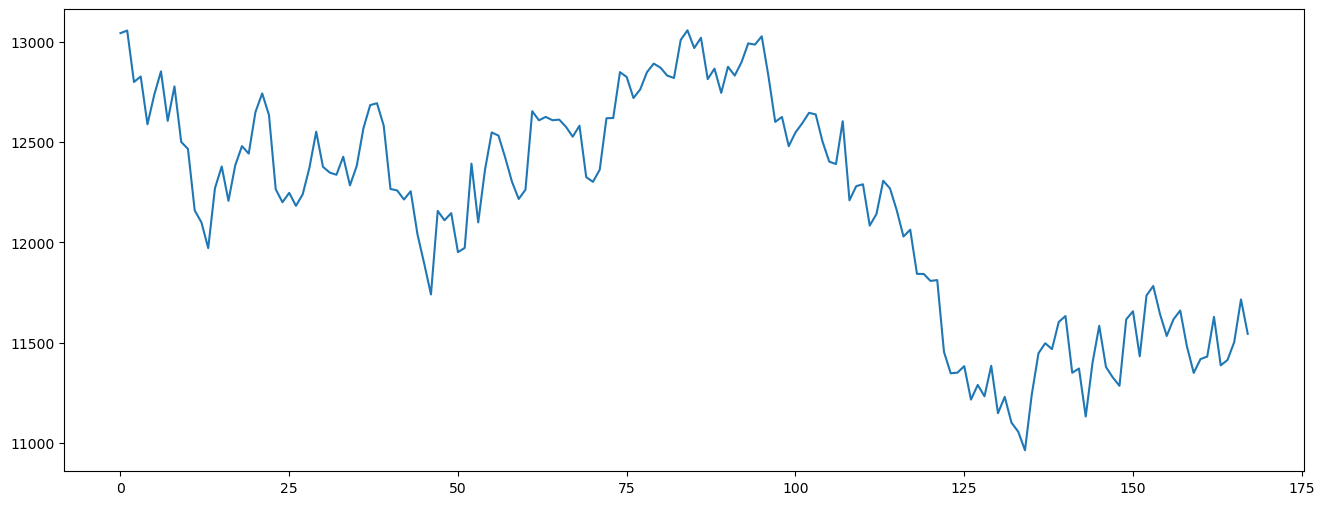

In [127]:
plt\
    .figure(figsize = [16, 6]
           )

plt\
    .plot(dow[ : , 5]
         )

#### Question 10-5. Now over-plot this plot with a `red dot` marker for every day where the dow volume was greater than 5.5 billion.

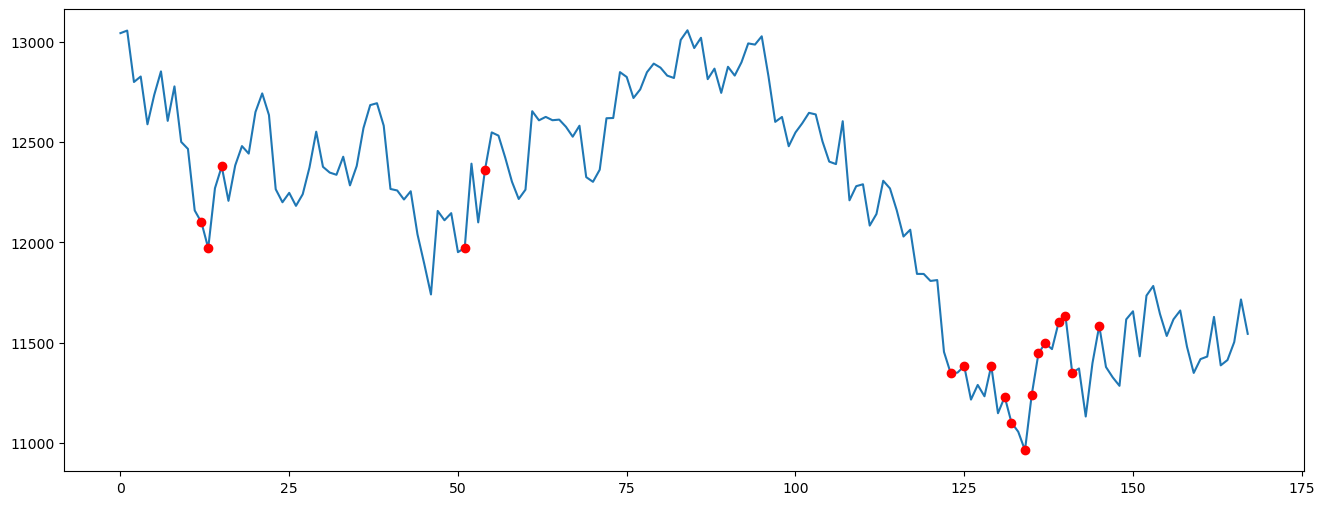

In [128]:
plt\
    .figure(figsize = [16, 6]
           )

plt\
    .plot(dow[ : , 5]
         )

plt\
    .plot(where(masking)[0],
          dow[where(masking)[0], 5],
          "ro"
         )

### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>